
# Ensemble Classifiers I: Linear vs. Nonlinear Classification

In the previous notebook, we introduced logistic regression as a method for binary classification.
Logistic regression works well when the boundary between two classes is approximately linear.

In many real datasets, however, the relationship between variables and class membership is not purely linear.
In those cases, we often need more flexible models.

In this notebook, we will:

1. Review the idea of linear vs. nonlinear classification.
2. Visualize how different classifiers separate the same data.
3. Learn the basic intuition behind decision trees.
4. See how random forests improve on single trees.
5. Briefly compare these approaches to k-nearest neighbors (kNN).

The emphasis here is on **intuition and visualization**, not on mathematical derivations.


In [1]:
# a helper function to clear plots 
import matplotlib.pyplot as plt
import numpy as np
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.8, label="Class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.8, label="Class 1")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Text(0, 0.5, 'Feature 2')

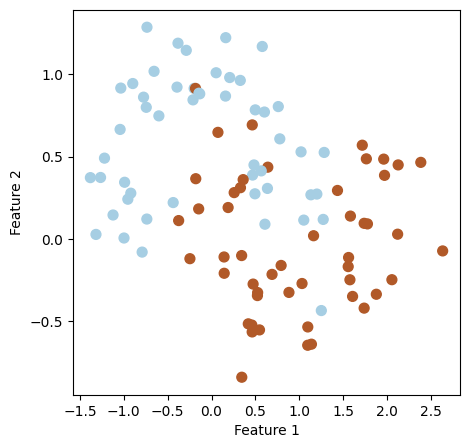

In [19]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

Xm, ym = make_moons(n_samples=100, noise=0.25, random_state=53)
# plot the data
fig, ax = plt.subplots(figsize=(5, 5))
point_style = dict(cmap='Paired', s=50)
ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, **point_style)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

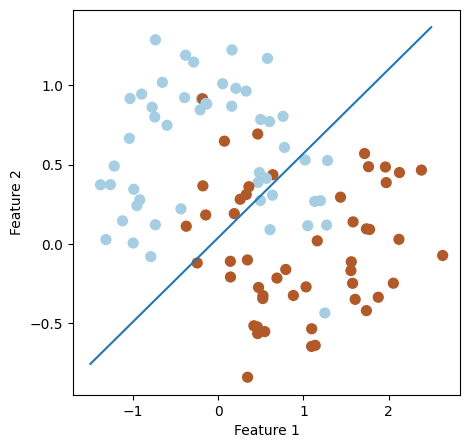

In [20]:
#fit a linear model to this data and see the decision boundary

from sklearn.linear_model import LogisticRegression

#fit the model
log_reg = LogisticRegression()
log_reg.fit(Xm,np.ravel(ym))

# plot the data
fig, ax = plt.subplots(figsize=(5, 5))
point_style = dict(cmap='Paired', s=50)
ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, **point_style)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

#to plot the boundary 
# 2. Extract coefficients
# log_reg.coef_ is a 2D array as there are two features: [[beta1, beta2]]
# log_reg.intercept_ is a 1D array: [beta0]
beta0 = log_reg.intercept_[0]
beta1, beta2 = log_reg.coef_[0]


x_ = np.linspace(-1.5,2.5,100)
y_ = -(beta0/beta2 + (beta1/beta2)*x_)
plt.plot(x_,y_)


This is not great, the boundary does not properly split the groups. We need another alternative to properly separate the classe. 

## Decision Trees 

A decision tree is a very intuitive way to separate data into different classes. Decision trees work by separating the data using binary rules. In principle, a decision tree repeatedly asks simple yes-or-no questions about the input features, splitting the data into smaller and more homogeneous groups until it reaches a final classification decision.

The decision tree classification algorithm will literally go over all possible features and evaluate many possible threshold values for each feature, selecting at every step the split that produces the best separation between classes according to a chosen criterion.

The most commonly used criteria is the *Gini Impurity*, defined as 
$$
G_i = 1 - \sum_{k=1}^{n}p^{2}_{i,k}
$$
where $p_{i,k}$ is the ratio of class $k$ samples among all the traning samples in a given node. 

At each node of the decision tree, the algorithm will find the best feature and the best threshold that produces the lowest cost function

$$
L(k) = \frac{m_{left}}{m}G_{left} + \frac{m_{right}}{m}G_{right}
$$

where $m$ is the total number of samples in the node, $m_{right}$ ($m_{left}) are the amount of samples that will be assigned to rigth (left) side of the tree, and $G_{right}$ (G_{left}) are the resulting Gini Impurity.

The algorithm works one node at the time, so there is no way to know how selections in the current node will affect noder down the tree.



In [11]:
import ipywidgets as widgets
from IPython.display import display, Markdown

def gini_impurity(labels):
    if len(labels) == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    return 1 - np.sum(probs**2)

# Precompute Gini scores for every feature/threshold pair
gini_results = {}
parent_gini = gini_impurity(ym)

for f in range(Xm.shape[1]):
    values = Xm[:, f]
    unique_vals = np.unique(values)
    thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2

    rows = []
    for t in thresholds:
        left_mask = values <= t
        right_mask = values > t

        y_left = ym[left_mask]
        y_right = ym[right_mask]

        g_left = gini_impurity(y_left)
        g_right = gini_impurity(y_right)

        weighted_gini = (len(y_left) / len(ym)) * g_left + (len(y_right) / len(ym)) * g_right
        gain = parent_gini - weighted_gini

        rows.append(
            {
                "threshold": t,
                "n_left": len(y_left),
                "n_right": len(y_right),
                "gini_left": g_left,
                "gini_right": g_right,
                "weighted_gini": weighted_gini,
                "gain": gain,
            }
        )
    gini_results[f] = rows

# Interactive controls
feature_slider = widgets.IntSlider(
    value=0, min=0, max=Xm.shape[1] - 1, step=1, description="Feature"
)
threshold_slider = widgets.IntSlider(
    value=0, min=0, max=len(gini_results[0]) - 1, step=1, description="Threshold idx"
)

def _sync_threshold_slider(change):
    f = change["new"]
    threshold_slider.max = max(0, len(gini_results[f]) - 1)
    threshold_slider.value = min(threshold_slider.value, threshold_slider.max)

feature_slider.observe(_sync_threshold_slider, names="value")

def show_split(feature, threshold_idx):
    row = gini_results[feature][threshold_idx]
    t = row["threshold"]

    display(Markdown(
        f"""
**Feature {feature + 1}**  
- Threshold: `{t:.4f}`  
- Left count: `{row['n_left']}` | Right count: `{row['n_right']}`  
- Gini(left): `{row['gini_left']:.4f}` | Gini(right): `{row['gini_right']:.4f}`  
- Weighted Gini: `{row['weighted_gini']:.4f}`  
- Gini Gain: `{row['gain']:.4f}`
"""
    ))

    plt.figure(figsize=(6, 5))
    plt.scatter(Xm[ym == 0, 0], Xm[ym == 0, 1], alpha=0.8, label="Class 0")
    plt.scatter(Xm[ym == 1, 0], Xm[ym == 1, 1], alpha=0.8, label="Class 1")

    if feature == 0:
        plt.axvline(t, color="black", linestyle="--", label=f"x0 <= {t:.2f}")
    else:
        plt.axhline(t, color="black", linestyle="--", label=f"x1 <= {t:.2f}")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Iterative Gini Split Viewer")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

ui = widgets.VBox([feature_slider, threshold_slider])
out = widgets.interactive_output(show_split, {"feature": feature_slider, "threshold_idx": threshold_slider})
display(ui, out)

Output()

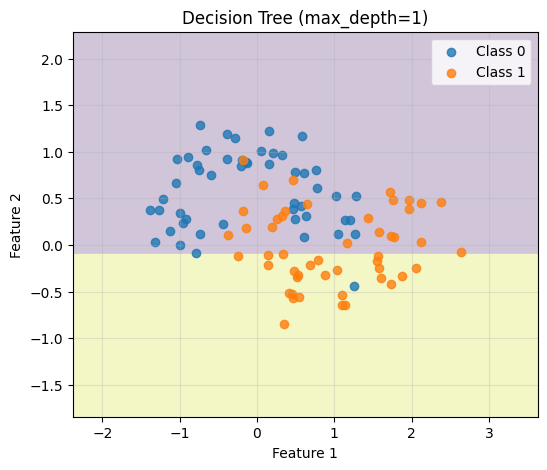

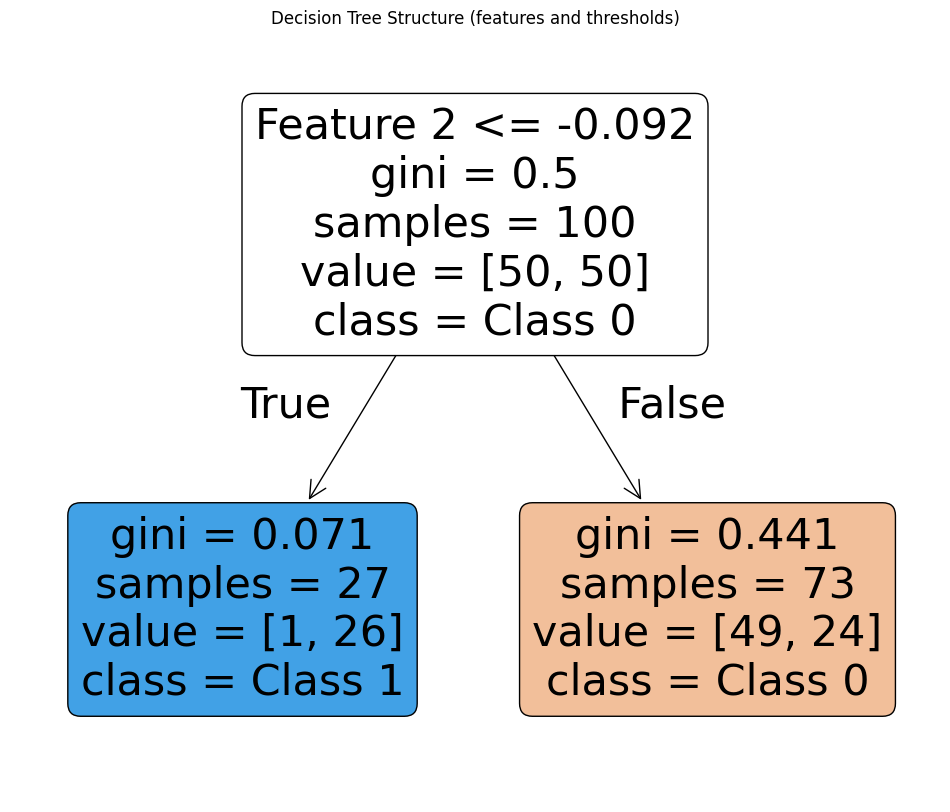

In [12]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

# Train a shallow decision tree (two levels of splits)
tree_2lvl = DecisionTreeClassifier(max_depth=1, random_state=53)
tree_2lvl.fit(Xm, ym)

# 1) Plot decision boundary on the moon data
plot_decision_boundary(tree_2lvl, Xm, ym, title="Decision Tree (max_depth=1)")

# 2) Plot the tree structure with selected features and thresholds
plt.figure(figsize=(12, 10))
plot_tree(
    tree_2lvl,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Structure (features and thresholds)")
plt.show()


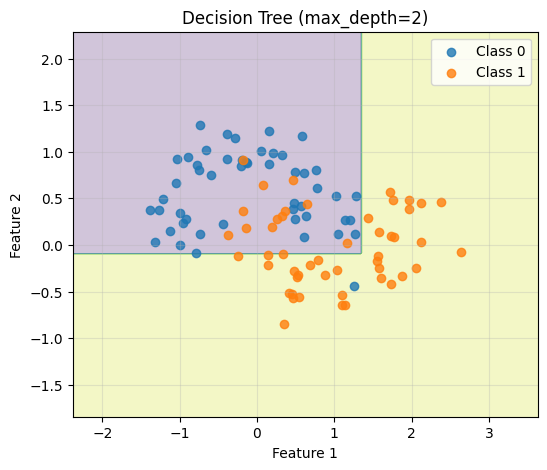

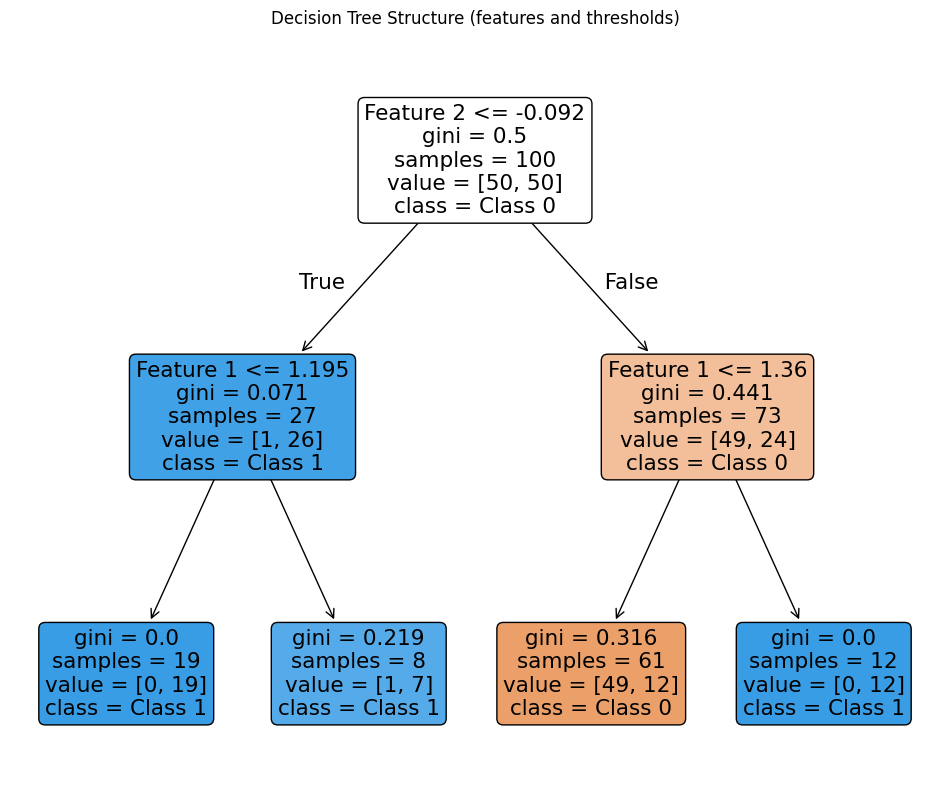

In [13]:

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

# Train a shallow decision tree (two levels of splits)
tree_2lvl = DecisionTreeClassifier(max_depth=2, random_state=53)
tree_2lvl.fit(Xm, ym)

# 1) Plot decision boundary on the moon data
plot_decision_boundary(tree_2lvl, Xm, ym, title="Decision Tree (max_depth=2)")

# 2) Plot the tree structure with selected features and thresholds
plt.figure(figsize=(12, 10))
plot_tree(
    tree_2lvl,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Structure (features and thresholds)")
plt.show()


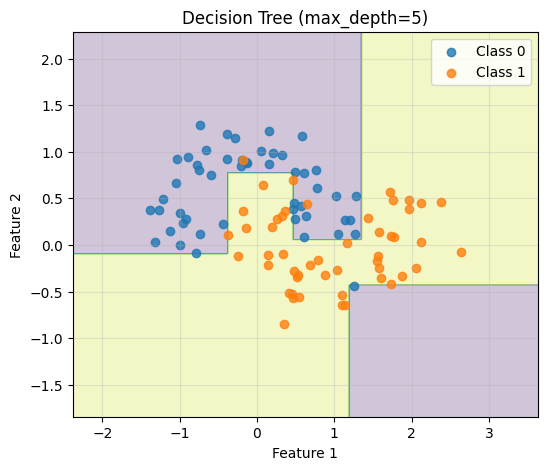

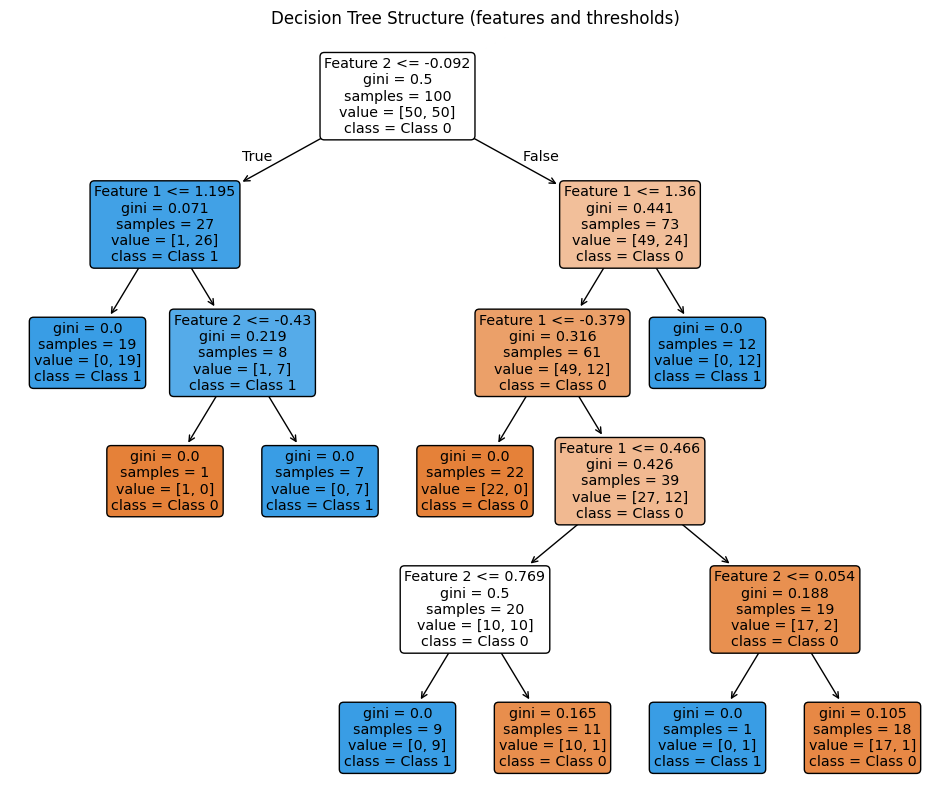

In [14]:

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

# Train a shallow decision tree (two levels of splits)
tree_2lvl = DecisionTreeClassifier(max_depth=5, random_state=53)
tree_2lvl.fit(Xm, ym)

# 1) Plot decision boundary on the moon data
plot_decision_boundary(tree_2lvl, Xm, ym, title="Decision Tree (max_depth=5)")

# 2) Plot the tree structure with selected features and thresholds
plt.figure(figsize=(12, 10))
plot_tree(
    tree_2lvl,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Structure (features and thresholds)")
plt.show()


## Limitations:
Decision Trees can grow up to having a single element per node. When this happend, the model has learned the training data perfectly, but it will produce poor results for the testing/validation data. It is important to always validate your model with testing data

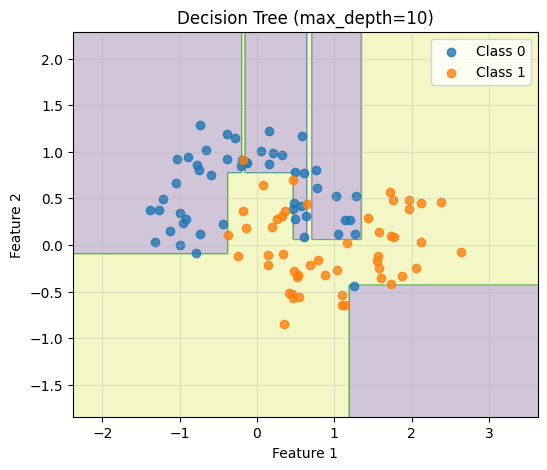

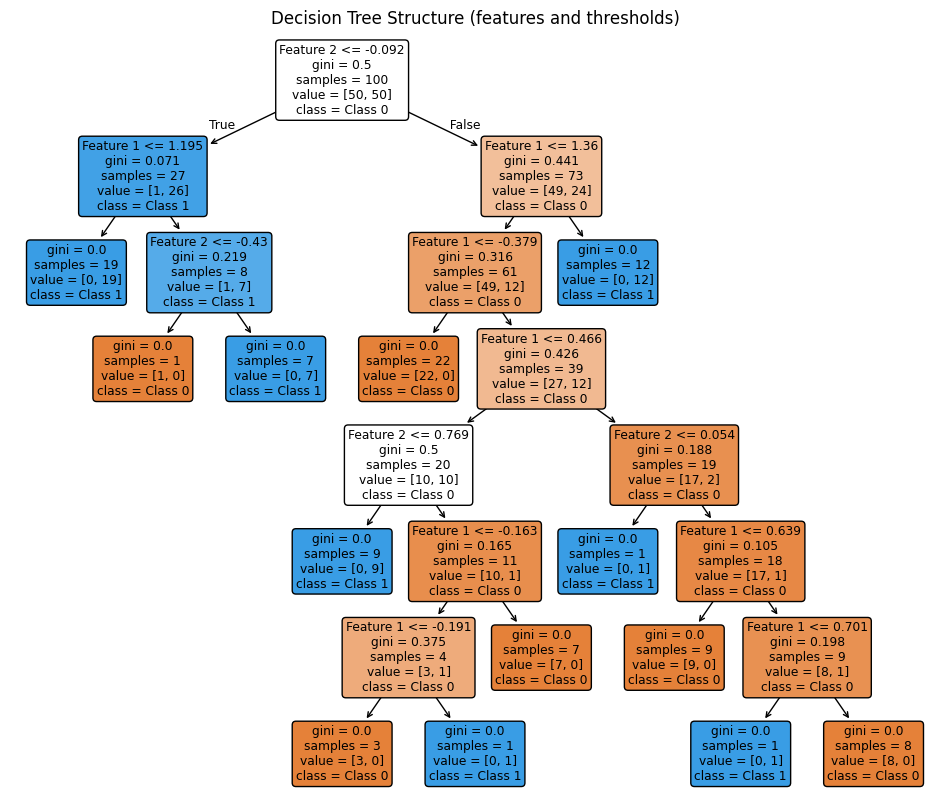

In [27]:

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

# Train a shallow decision tree (two levels of splits)
tree_2lvl = DecisionTreeClassifier(max_depth=10, random_state=53)
tree_2lvl.fit(Xm, ym)

# 1) Plot decision boundary on the moon data
plot_decision_boundary(tree_2lvl, Xm, ym, title="Decision Tree (max_depth=10)")

# 2) Plot the tree structure with selected features and thresholds
plt.figure(figsize=(12, 10))
plot_tree(
    tree_2lvl,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Structure (features and thresholds)")
plt.show()


## Random Forests

A random forest is an ensemble of many decision trees. To create a random forest, you split your data into different subset (as many sets as trees in the forest). Each subset will contain a random sample of the data (including samples and features), and this data will be used to train a decision tree. 

Instead of relying on the results provided by a single three, a random forest combines predictions from all the trees in the forest, each trained on slightly different versions of the data.

This usually helps because:
- it reduces sensitivity to one specific training sample,
- it often improves generalization,
- it helps to identify important features for classication by identifying what features are most influential for classification.


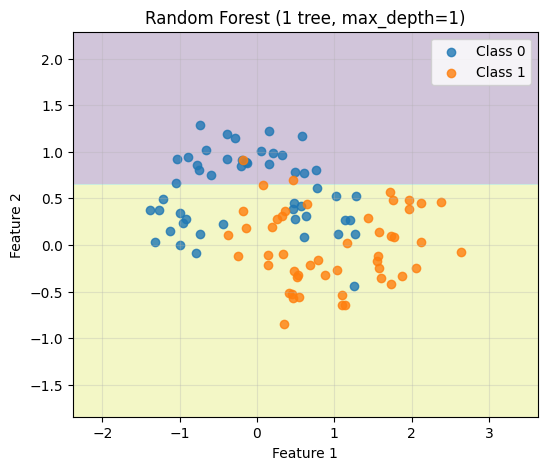

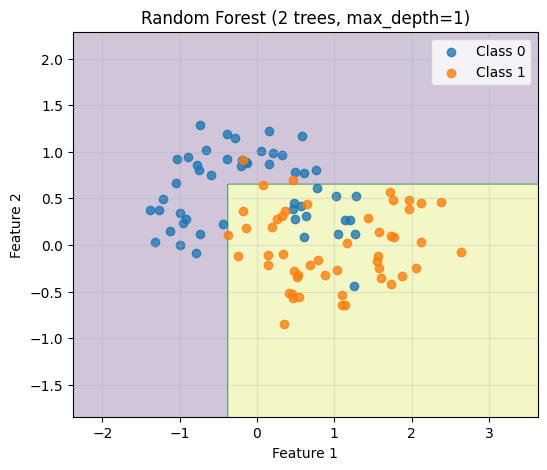

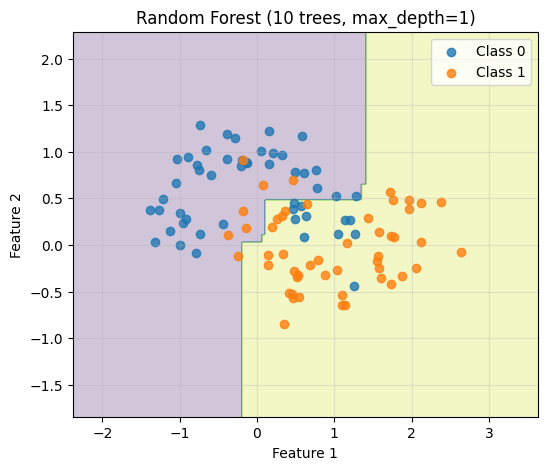

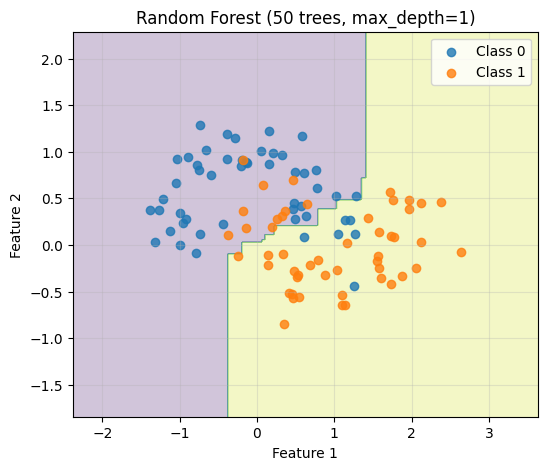

In [28]:
from sklearn.ensemble import RandomForestClassifier


forest_lonely = RandomForestClassifier(n_estimators=1, max_depth=1, random_state=42)
forest_small = RandomForestClassifier(n_estimators=2, max_depth=1, random_state=42)
forest_medium = RandomForestClassifier(n_estimators=10, max_depth=1, random_state=42)
forest_large = RandomForestClassifier(n_estimators=50, max_depth=1, random_state=42)

forest_lonely.fit(Xm, ym)
forest_small.fit(Xm, ym)
forest_medium.fit(Xm, ym)
forest_large.fit(Xm, ym)

plot_decision_boundary(forest_lonely, Xm, ym, title="Random Forest (1 tree, max_depth=1)")
plot_decision_boundary(forest_small, Xm, ym, title="Random Forest (2 trees, max_depth=1)")
plot_decision_boundary(forest_medium, Xm, ym, title="Random Forest (10 trees, max_depth=1)")
plot_decision_boundary(forest_large, Xm, ym, title="Random Forest (50 trees, max_depth=1)")

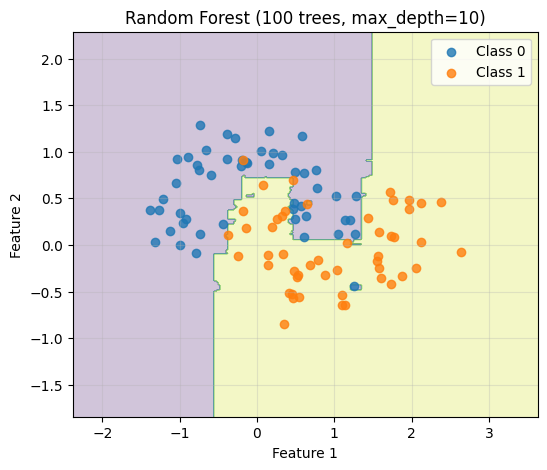

In [16]:

# you can also increase the depth of the trees in the forest to see how it affects the decision boundary
# the best model will be the one that generalized the best to the data, which is often a balance between having enough trees and 
# allowing them to be complex enough to capture the patterns in the data without overfitting
forest = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
forest.fit(Xm, ym)
plot_decision_boundary(forest, Xm, ym, title="Random Forest (100 trees, max_depth=10)")

## Model Evaluation Metrics: How Do We Compare Classifiers?

When we train classification models, we need ways to evaluate how well they perform.  
Different metrics capture **different aspects of performance**, especially when classes are imbalanced or when certain types of errors are more important than others.

Below are some commonly used metrics and how to interpret them.

---

### Accuracy

**What it measures:**  
Accuracy is the proportion of all predictions that the model gets correct.

**How it is computed:**  
Count how many predictions are correct and divide by the total number of predictions.

**Intuition:**  
Accuracy answers the question:

> *“Out of all cases, how often is the model right?”*

**Important limitation:**  
Accuracy can be misleading when classes are imbalanced.  
For example, if 90% of subjects are healthy, a model that always predicts “healthy” will have 90% accuracy but is clearly not useful.

---

### Precision

**What it measures:**  
Precision focuses on the reliability of **positive predictions**.

**How it is computed:**  
Among all cases that the model predicts as positive, calculate the proportion that are actually positive.

**Intuition:**  
Precision answers the question:

> *“When the model predicts impairment, how often is it correct?”*

**When it matters:**  
Precision is important when **false positives are costly**, such as unnecessary clinical interventions.

---

### Recall (Sensitivity)

**What it measures:**  
Recall focuses on how well the model identifies all true positive cases.

**How it is computed:**  
Among all truly positive cases, calculate the proportion that the model correctly identifies.

**Intuition:**  
Recall answers the question:

> *“Out of all impaired subjects, how many did the model successfully detect?”*

**When it matters:**  
Recall is important when **missing a true case is costly**, such as failing to detect a disease.

---

### F1 Score

**What it measures:**  
The F1 score combines precision and recall into a single value.

**How it is computed:**  
It is a type of average that becomes high only when **both precision and recall are high**.

**Intuition:**  
The F1 score answers the question:

> *“Does the model balance detecting true cases and avoiding false alarms?”*

**Why it is useful:**  
It is especially helpful when classes are imbalanced and when both types of errors matter.

---

### ROC Curve and ROC AUC

**What it measures:**  
The ROC curve evaluates how well a model separates the two classes across **all possible classification thresholds**.

**How it is constructed:**  
- The model produces a probability of belonging to the positive class.
- By changing the threshold used to classify cases as positive or negative, we obtain different combinations of:
  - **True positive rate (recall)**
  - **False positive rate**

These combinations form the ROC curve.

**ROC AUC (Area Under the Curve):**  
The ROC AUC summarizes the ROC curve into a single number between 0 and 1.

**Intuition:**  
ROC AUC answers the question:

> *“How well can the model distinguish between the two classes overall?”*

- A value near **0.5** means the model is no better than random guessing.
- A value near **1.0** means excellent separation between classes.

**Why it is useful:**  
ROC AUC is threshold-independent and is often a good metric for comparing models during training.

---

### Key Takeaways

- **Accuracy** measures overall correctness but can be misleading with imbalanced data.
- **Precision** measures how trustworthy positive predictions are.
- **Recall** measures how well the model detects true positive cases.
- **F1 score** balances precision and recall.
- **ROC AUC** measures how well the model separates classes across thresholds.

In practice, the “best” metric depends on the **clinical or practical context** and the relative importance of different types of errors.

## Model Evaluation Metrics: How Do We Compare Classifiers?

When we train classification models, we need ways to evaluate how well they perform.  
Different metrics capture **different aspects of performance**, especially when classes are imbalanced or when certain types of errors are more important than others.

A useful starting point is the **confusion matrix**.

---

### Confusion Matrix

A confusion matrix summarizes the model’s predictions by comparing **predicted class** vs **true class**.

For a binary classification problem:

|                     | **Predicted Negative** | **Predicted Positive** |
|---------------------|----------------------|------------------------|
| **True Negative**   | True Negative (TN)   | False Positive (FP)    |
| **True Positive**   | False Negative (FN)  | True Positive (TP)     |

**Interpretation:**

- **True Positive (TP):** model correctly predicts a positive case  
- **True Negative (TN):** model correctly predicts a negative case  
- **False Positive (FP):** model predicts positive but the case is actually negative  
- **False Negative (FN):** model predicts negative but the case is actually positive  

The confusion matrix helps us understand **what types of mistakes the model is making**, not just how often it is correct.

---

### Accuracy

**What it measures:**  
The proportion of all predictions that are correct.

**How to compute:**

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Intuition:**

> “Out of all cases, how often is the model correct?”

**Limitation:**  
Accuracy can be misleading when one class is much more common than the other.

---

### Precision

**What it measures:**  
How reliable the model’s **positive predictions** are.

**How to compute :**

$$
Precision = \frac{TP}{TP + FP}
$$

**Intuition:**

> “When the model predicts impairment, how often is it right?”

Precision decreases when the model produces many **false positives**.

---

### Recall (Sensitivity)

**What it measures:**  
How well the model detects **all true positive cases**.

**How to compute :**

$$
Recall = \frac{TP}{TP + FN}
$$

**Intuition:**

> “Out of all impaired subjects, how many did the model successfully identify?”

Recall decreases when the model produces many **false negatives**.

---

### F1 Score

**What it measures:**  
A balance between precision and recall.

**How to compute :**  
The F1 score combines **precision** and **recall** into a single metric:
$$
F1 = \frac{2 \cdot (Precision \cdot Recall)}{Precision + Recall}
$$

This is called the **harmonic mean** of precision and recall.

**Intuition:**

> “Does the model both detect true cases and avoid false alarms?”

The F1 score becomes high **only when both precision and recall are high**.

- If precision is high but recall is low → F1 will be low  
- If recall is high but precision is low → F1 will be low  
- If both are high → F1 will be high  

This makes the F1 score useful when we want a model that:

> detects true cases **and** avoids false alarms.

##### Why not just average precision and recall?

A simple average could still be high if one metric is very high and the other is very low.  
The harmonic mean used in the F1 score **penalizes large imbalances**, encouraging models that perform well on both measures.

---

### ROC Curve and ROC AUC

**What it measures:**  
How well the model separates the two classes across **all possible classification thresholds**.

**How it works :**

- The model produces a probability of belonging to the positive class.
- By changing the classification threshold, we obtain different combinations of:
  - **True Positive Rate (Recall)**
  - **False Positive Rate**

These combinations form the **ROC curve**.

**ROC AUC (Area Under the Curve):**

- A single value summarizing the ROC curve.
- Values range from **0.5 (random guessing)** to **1.0 (perfect separation)**.

**Intuition:**

> “How well can the model distinguish between the two classes overall?”

ROC AUC is useful for **comparing models during training**, because it does not depend on choosing one specific threshold.


Logistic Regression
Confusion Matrix:
[[8 4]
 [4 9]]
Accuracy : 0.680
Precision: 0.692
Recall   : 0.692
F1-score : 0.692
ROC AUC  : 0.853

Random Forest
Confusion Matrix:
[[10  2]
 [ 2 11]]
Accuracy : 0.840
Precision: 0.846
Recall   : 0.846
F1-score : 0.846
ROC AUC  : 0.926


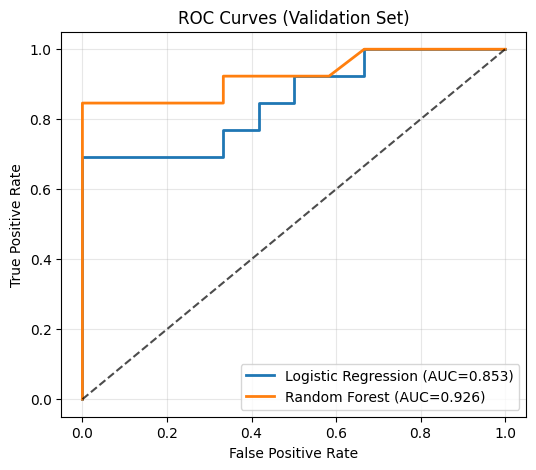

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    Xm, ym, test_size=0.25, random_state=53, stratify=ym
)

# Models
log_reg_cmp = LogisticRegression(max_iter=1000, random_state=53)
rf_cmp = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=53)

# Fit
log_reg_cmp.fit(X_train, y_train)
rf_cmp.fit(X_train, y_train)

# Validate
y_pred_log = log_reg_cmp.predict(X_val)
y_pred_rf = rf_cmp.predict(X_val)



from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)

model_outputs = {
    "Logistic Regression": {
        "y_pred": y_pred_log,
        "y_prob": log_reg_cmp.predict_proba(X_val)[:, 1],
    },
    "Random Forest": {
        "y_pred": y_pred_rf,
        "y_prob": rf_cmp.predict_proba(X_val)[:, 1],
    },
}

for name, out in model_outputs.items():
    cm = confusion_matrix(y_val, out["y_pred"])
    acc = accuracy_score(y_val, out["y_pred"])
    prec = precision_score(y_val, out["y_pred"])
    rec = recall_score(y_val, out["y_pred"])
    f1 = f1_score(y_val, out["y_pred"])
    auc = roc_auc_score(y_val, out["y_prob"])

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    print(f"ROC AUC  : {auc:.3f}")

plt.figure(figsize=(6, 5))
for name, out in model_outputs.items():
    fpr, tpr, _ = roc_curve(y_val, out["y_prob"])
    auc = roc_auc_score(y_val, out["y_prob"])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()